In [1]:
import numpy as np
import torch 
import matplotlib.pyplot as plt

from GENERAL_FUNCTIONS.functions_torch import *
from ATMOSPHERE.atmosphere import *
from PYRAMID.Pyramid_WFS import *
import torch.nn.functional as F
from MODAL_BASIS.Zernike import * 

In [2]:
RAMA_DATA = np.load("OnSkyRef.npy")

sz = 36
rama_coords = [[17,8],
               [74,11],
               [22,70],
               [74,11]]
rama_pupils = np.zeros((4,sz,sz))
for Index,coords in enumerate(rama_coords):
    rama_pupils[Index,...] = RAMA_DATA[coords[1]:coords[1]+sz,coords[0]:coords[0]+sz]/np.max(RAMA_DATA[coords[1]:coords[1]+sz,coords[0]:coords[0]+sz])
pupils = np.hstack((np.vstack((rama_pupils[0],rama_pupils[1])),np.vstack((rama_pupils[2],rama_pupils[3]))))

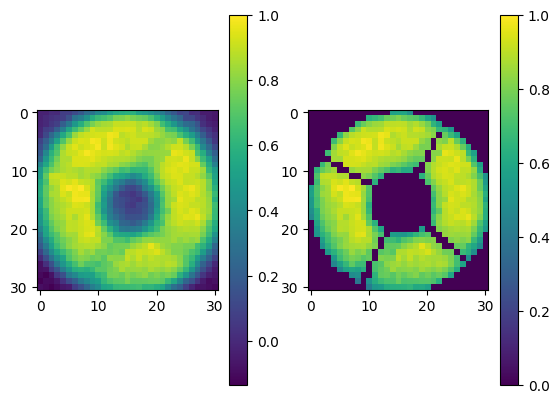

In [3]:
device = "cpu"
dtype = torch.float32
precision = get_precision("single")
telescope_diameter = 3.0 # meters
telescope_resolution = 128 # pixels
telescope_samp = 2
telescope_obstruction_diameter = 28 # pixels
telescope_spiders = 4 # scalar
telescope_spiders_pixels = 1 # pixels
telescope_spiders_degree = 20
telescope_pupil = circular_pupil_telescope(
    n=128,
    central_obstruction_diam_px=45.0,
    # x, y exactos
    central_obstruction_center_px=(
        128.0//2,
        128.0//2,
    ),
    spiders_px=5.0,
    # EJEMPLO: reemplazar por los ángulos que midas
    spider_angles_deg=(
        -60.0,
        42,
        115,
        210
    ),
    device="cpu",
    dtype=torch.float32,
)
telescope_pupil_clean = circular_pupil(128,device=device,dtype=dtype)
zDecomposeMat,zComposeMat = get_zernike(telescope_pupil_clean.squeeze(),0.6, 2,type="torch")
output_resolution = 36
wfs = Pyramid(telescope_resolution=telescope_resolution, telescope_diameter=telescope_diameter,
              telescope_samp=telescope_samp, output_resolution = output_resolution,
              nHeads=4, alpha= 2.8,device=device,precision=precision,offset=10)
zVec = torch.zeros((1,2))
zVec[0,0] = -10
zVec[0,1] = 10
phi = zernike_compose_torch(zVec,zComposeMat=zComposeMat.to(dtype))
I = wfs.propagate(pupil= telescope_pupil,phi= phi).squeeze().numpy()
pupils_simulated = np.vstack((np.hstack((I[0],I[1])),np.hstack((I[3],I[2]))))
plt.subplot(1,2,1)
x,y,sz = 3,2,31
rama_roi = (rama_pupils[1,y:y+sz,x:x+sz])
plt.imshow((rama_pupils[1,y:y+sz,x:x+sz]),cmap="viridis")
plt.colorbar()
plt.subplot(1,2,2)
x,y,sz = 2,2,31
plt.imshow((I[1,y:y+sz,x:x+sz]>0.2)*(rama_roi),cmap= "viridis")
plt.colorbar()